In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

df = pd.read_csv('../data/ipl.csv')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (76014, 15)


,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (76014, 15)

Columns:
['mid', 'date', 'venue', 'bat_team', 'bowl_team', 'batsman', 'bowler', 'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5', 'striker', 'non-striker', 'total']

Data types:
mid                 int64
date               object
venue              object
bat_team           object
bowl_team          object
batsman            object
bowler             object
runs                int64
wickets             int64
overs             float64
runs_last_5         int64
wickets_last_5      int64
striker             int64
non-striker         int64
total               int64
dtype: object

Missing values:
mid               0
date              0
venue             0
bat_team          0
bowl_team         0
batsman           0
bowler            0
runs              0
wickets           0
overs             0
runs_last_5       0
wickets_last_5    0
striker           0
non-striker       0
total             0
dtype: int64


In [5]:
print(df['total'].describe())

count    76014.000000
mean       160.901452
std         29.246231
min         67.000000
25%        142.000000
50%        162.000000
75%        181.000000
max        263.000000
Name: total, dtype: float64


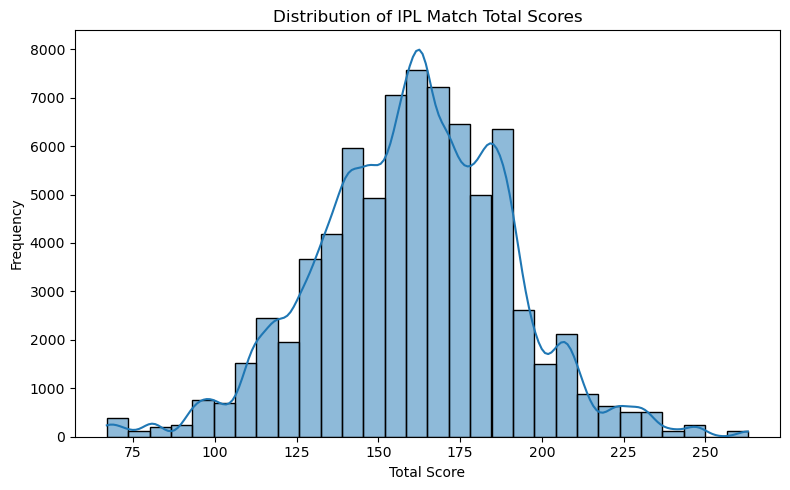

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df['total'], bins=30, kde=True)

plt.title('Distribution of IPL Match Total Scores')
plt.xlabel('Total Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [7]:
print("Unique matches:", df['mid'].nunique())

total_per_match = df.groupby('mid')['total'].nunique()

print("\nNumber of unique total values per match:")
print(total_per_match.value_counts())

Unique matches: 617

Number of unique total values per match:
total
1    617
Name: count, dtype: int64


In [8]:
match_df = (
    df.groupby('mid')
      .agg({
          'date': 'first',
          'venue': 'first',
          'bat_team': 'first',
          'bowl_team': 'first',
          'total': 'first'
      })
      .reset_index()
)

print("Match-level shape:", match_df.shape)
match_df.head()

Match-level shape: (617, 6)


,mid,date,venue,bat_team,bowl_team,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,222
1,2,2008-04-19,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,Kings XI Punjab,240
2,3,2008-04-19,Feroz Shah Kotla,Rajasthan Royals,Delhi Daredevils,129
3,4,2008-04-20,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,165
4,5,2008-04-20,Eden Gardens,Deccan Chargers,Kolkata Knight Riders,110


In [9]:
q33 = match_df['total'].quantile(1/3)
q67 = match_df['total'].quantile(2/3)

print("33rd percentile:", q33)
print("67th percentile:", q67)

match_df['score_category'] = pd.cut(
    match_df['total'],
    bins=[-np.inf, q33, q67, np.inf],
    labels=['Low', 'Medium', 'High']
)

print("\nClass distribution:")
print(match_df['score_category'].value_counts())

33rd percentile: 148.0
67th percentile: 173.0

Class distribution:
score_category
Low       208
Medium    208
High      201
Name: count, dtype: int64


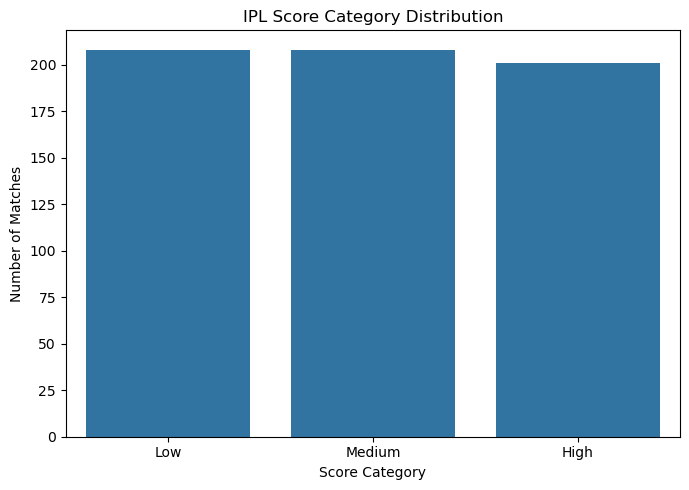

In [10]:
plt.figure(figsize=(7, 5))
sns.countplot(data=match_df, x='score_category')

plt.title('IPL Score Category Distribution')
plt.xlabel('Score Category')
plt.ylabel('Number of Matches')
plt.tight_layout()
plt.show()

In [11]:
X = match_df[['venue', 'bat_team', 'bowl_team']]
y = match_df['score_category']

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
['venue', 'bat_team', 'bowl_team']

Target:
score_category

Feature shape: (617, 3)
Target shape: (617,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training set shape: (493, 3)
Test set shape: (124, 3)

Training class distribution:
score_category
Low       166
Medium    166
High      161
Name: count, dtype: int64

Test class distribution:
score_category
Low       42
Medium    42
High      40
Name: count, dtype: int64


In [13]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)

Encoded training shape: (493, 63)
Encoded test shape: (124, 63)


In [14]:
target_encoder = LabelEncoder()

y_train_encoded = target_encoder.fit_transform(y_train)
y_test_encoded = target_encoder.transform(y_test)

print("Class mapping:")
for label, code in zip(target_encoder.classes_, range(len(target_encoder.classes_))):
    print(f"{label} -> {code}")

Class mapping:
High -> 0
Low -> 1
Medium -> 2


In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled training shape: (493, 63)
Scaled test shape: (124, 63)


In [16]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logreg.fit(X_train_scaled, y_train_encoded)

y_pred_logreg = logreg.predict(X_test_scaled)

print("Logistic Regression trained successfully.")
print("Predictions:", y_pred_logreg[:10])

Logistic Regression trained successfully.
Predictions: [1 0 1 2 2 2 1 0 0 1]


In [17]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train_encoded)

y_pred_knn = knn.predict(X_test_scaled)

print("K-Nearest Neighbors trained successfully.")
print("Predictions:", y_pred_knn[:10])

K-Nearest Neighbors trained successfully.
Predictions: [1 0 0 2 2 1 1 0 0 0]


In [18]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(X_train_scaled, y_train_encoded)

y_pred_gnb = gnb.predict(X_test_scaled)

print("Gaussian Naive Bayes trained successfully.")
print("Predictions:", y_pred_gnb[:10])

Gaussian Naive Bayes trained successfully.
Predictions: [1 0 0 0 0 0 1 0 0 0]


In [19]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train_scaled, y_train_encoded)

y_pred_dt = dt.predict(X_test_scaled)

print("Decision Tree Classifier trained successfully.")
print("Predictions:", y_pred_dt[:10])


Decision Tree Classifier trained successfully.
Predictions: [0 1 2 1 0 0 1 0 0 0]


In [20]:
from sklearn.svm import SVC

svc = SVC(
    probability=True,
    random_state=42
)

svc.fit(X_train_scaled, y_train_encoded)

y_pred_svc = svc.predict(X_test_scaled)

print("Support Vector Classifier trained successfully.")
print("Predictions:", y_pred_svc[:10])

Support Vector Classifier trained successfully.
Predictions: [1 0 1 2 2 2 1 0 0 1]


In [21]:
models_predictions = {
    'Logistic Regression': y_pred_logreg,
    'KNN': y_pred_knn,
    'Gaussian Naive Bayes': y_pred_gnb,
    'Decision Tree': y_pred_dt,
    'SVC': y_pred_svc
}

results = []

for model_name, y_pred in models_predictions.items():
    accuracy = accuracy_score(y_test_encoded, y_pred)
    weighted_f1 = f1_score(
        y_test_encoded,
        y_pred,
        average='weighted'
    )

    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Weighted F1': weighted_f1
    })

results_df = pd.DataFrame(results)

print(results_df)

                  Model  Accuracy  Weighted F1
0   Logistic Regression  0.387097     0.384387
1                   KNN  0.306452     0.278540
2  Gaussian Naive Bayes  0.322581     0.207869
3         Decision Tree  0.322581     0.319549
4                   SVC  0.403226     0.396946


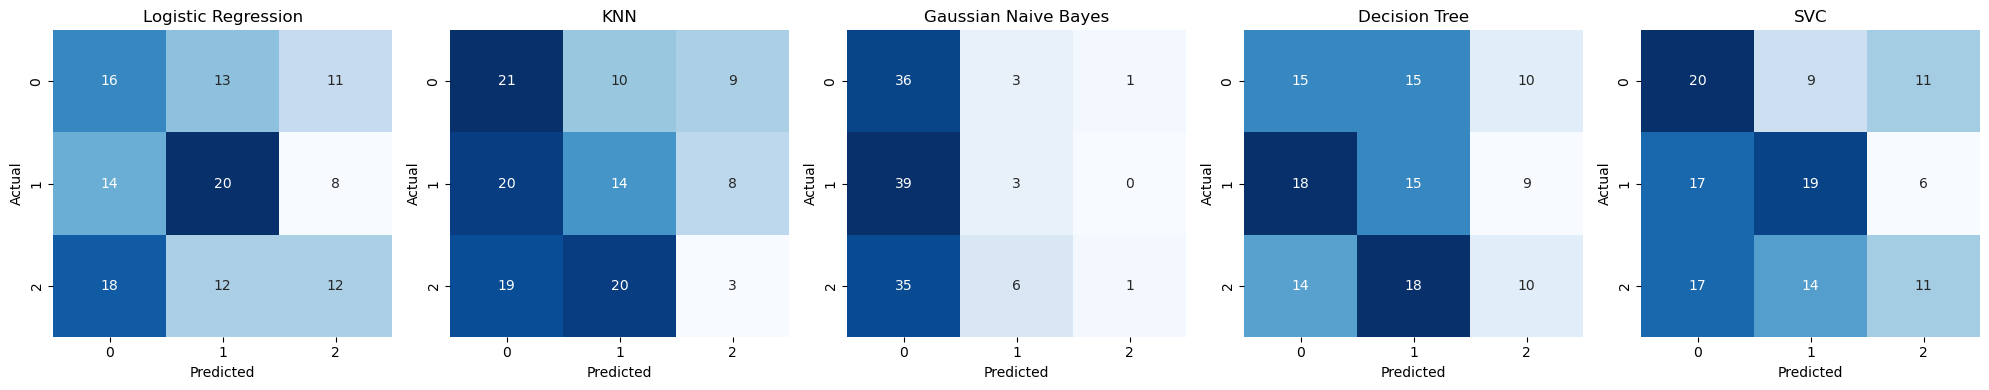

In [22]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (model_name, y_pred) in zip(axes, models_predictions.items()):
    cm = confusion_matrix(y_test_encoded, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=ax
    )

    ax.set_title(model_name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import precision_score, recall_score

detailed_results = []

for model_name, y_pred in models_predictions.items():
    detailed_results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test_encoded, y_pred),
        'Precision': precision_score(
            y_test_encoded,
            y_pred,
            average='weighted',
            zero_division=0
        ),
        'Recall': recall_score(
            y_test_encoded,
            y_pred,
            average='weighted',
            zero_division=0
        ),
        'Weighted F1': f1_score(
            y_test_encoded,
            y_pred,
            average='weighted'
        )
    })

detailed_results_df = pd.DataFrame(detailed_results)

print(detailed_results_df.round(4))

                  Model  Accuracy  Precision  Recall  Weighted F1
0   Logistic Regression    0.3871     0.3892  0.3871       0.3844
1                   KNN    0.3065     0.2715  0.3065       0.2785
2  Gaussian Naive Bayes    0.3226     0.3596  0.3226       0.2079
3         Decision Tree    0.3226     0.3256  0.3226       0.3195
4                   SVC    0.4032     0.4058  0.4032       0.3969


In [24]:
from sklearn.metrics import roc_auc_score

models_probabilities = {
    'Logistic Regression': logreg.predict_proba(X_test_scaled),
    'KNN': knn.predict_proba(X_test_scaled),
    'Gaussian Naive Bayes': gnb.predict_proba(X_test_scaled),
    'Decision Tree': dt.predict_proba(X_test_scaled),
    'SVC': svc.predict_proba(X_test_scaled)
}

roc_auc_results = []

for model_name, y_prob in models_probabilities.items():
    roc_auc = roc_auc_score(
        y_test_encoded,
        y_prob,
        multi_class='ovr',
        average='weighted'
    )

    roc_auc_results.append({
        'Model': model_name,
        'ROC-AUC (OvR)': roc_auc
    })

roc_auc_df = pd.DataFrame(roc_auc_results)

print(roc_auc_df.round(4))

                  Model  ROC-AUC (OvR)
0   Logistic Regression         0.5608
1                   KNN         0.5027
2  Gaussian Naive Bayes         0.5385
3         Decision Tree         0.5132
4                   SVC         0.5349


In [25]:
final_part_a_results = detailed_results_df.copy()

final_part_a_results['ROC-AUC (OvR)'] = roc_auc_df['ROC-AUC (OvR)']

final_part_a_results = final_part_a_results[
    ['Model', 'Accuracy', 'Precision', 'Recall', 'Weighted F1', 'ROC-AUC (OvR)']
]

print(final_part_a_results.round(4))

                  Model  Accuracy  Precision  Recall  Weighted F1  \
0   Logistic Regression    0.3871     0.3892  0.3871       0.3844   
1                   KNN    0.3065     0.2715  0.3065       0.2785   
2  Gaussian Naive Bayes    0.3226     0.3596  0.3226       0.2079   
3         Decision Tree    0.3226     0.3256  0.3226       0.3195   
4                   SVC    0.4032     0.4058  0.4032       0.3969   

   ROC-AUC (OvR)  
0         0.5608  
1         0.5027  
2         0.5385  
3         0.5132  
4         0.5349  


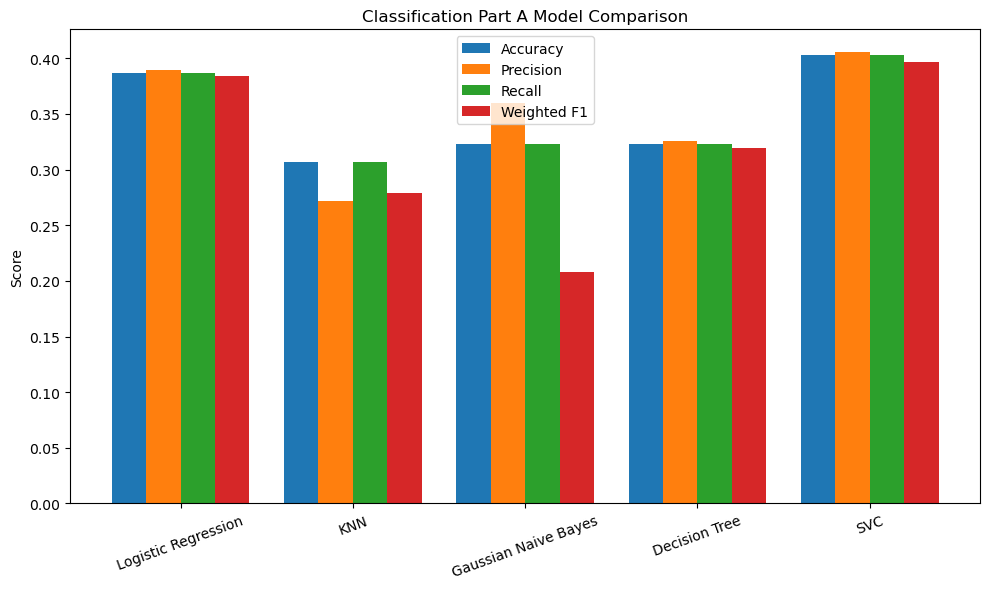

In [26]:
plt.figure(figsize=(10, 6))

x = np.arange(len(final_part_a_results))
width = 0.2

plt.bar(
    x - 1.5 * width,
    final_part_a_results['Accuracy'],
    width,
    label='Accuracy'
)

plt.bar(
    x - 0.5 * width,
    final_part_a_results['Precision'],
    width,
    label='Precision'
)

plt.bar(
    x + 0.5 * width,
    final_part_a_results['Recall'],
    width,
    label='Recall'
)

plt.bar(
    x + 1.5 * width,
    final_part_a_results['Weighted F1'],
    width,
    label='Weighted F1'
)

plt.xticks(x, final_part_a_results['Model'], rotation=20)
plt.ylabel('Score')
plt.title('Classification Part A Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
final_part_a_results.to_csv(
    '../data/classification_part_a_results.csv',
    index=False
)

print("Part A results saved successfully.")

Part A results saved successfully.
